
---

# 🧠 Convolutional Neural Network (CNN)

*Also known as: A computer’s eyes 👁️*

---

## 👶 Baby-Level Analogy

Imagine you give a drawing of a cat 🐱 to a robot.

A **normal neural network (ANN)** looks at **every pixel at once** and says: "Okay, here are 10,000 numbers… let’s try to figure it out."

A **CNN**, instead, says:

> “Wait! I’ll **look at small parts of the image**, like a window. I'll first check the eyes 👀, then the ears 👂, then the whiskers 🐾, and so on.”

It **slides** over the image, picks up features, and then builds up its understanding of **what’s in the picture**.

---

## 🔍 Why Not Use ANN for Images?

| Problem                          | ANN Limitation                                    |
| -------------------------------- | ------------------------------------------------- |
| Images are huge (e.g. 128x128x3) | Too many inputs and parameters                    |
| Patterns exist locally           | ANN doesn’t understand spatial relationships      |
| Translational variations         | ANN doesn’t recognize same object in new position |

So we use **CNN** instead. It is specially made for **spatial data** like **images**, **videos**, and **grids**.

---

## 🧱 CNN Architecture (Lego Block by Block)

```
INPUT IMAGE 🖼️
   ⬇️
[ CONVOLUTION LAYER 🔍 ]
   ⬇️
[ ACTIVATION FUNCTION 🔥 ]
   ⬇️
[ POOLING LAYER 💧 ]
   ⬇️
[ (Repeat Conv + Pool) ]
   ⬇️
[ FLATTEN 🧻 ]
   ⬇️
[ DENSE LAYERS 🧠 ]
   ⬇️
[ OUTPUT LAYER 🎯 ]
```

Let’s now define every block… atomically.

---

## 🧊 1. Input Layer

* Takes the image as a 3D matrix: e.g. `28 x 28 x 1` for grayscale, or `128 x 128 x 3` for RGB.

---

## 🔍 2. Convolution Layer (the star ⭐)

* Slides a **filter/kernel** over the image
* Each filter detects **patterns** like:

  * Edges ✂️
  * Corners ◼️
  * Textures 🧵

🔁 It performs this formula at every window:

```
Output = (Window ⊙ Filter) + Bias
```

> 👁️ Think of it like scanning the image with glasses that highlight edges, curves, etc.

---

## 🔥 3. Activation Function (like ReLU)

* Adds **non-linearity**
* Common function: `ReLU(x) = max(0, x)`
* Helps the network learn complex patterns

---

## 💧 4. Pooling Layer (Downsampling)

* Reduces size to make learning faster
* Keeps important features, throws away the rest
* Most common: **MaxPooling** — picks the biggest number in a region

| Original | After MaxPool |
| -------- | ------------- |
| 1 3      | 3             |
| 2 0      |               |

---

## 🧻 5. Flatten

* Converts 3D feature map to 1D vector
* Needed before connecting to a fully connected (dense) layer

---

## 🧠 6. Fully Connected (Dense) Layers

* Standard ANN layers
* Final decision-making happens here

---

## 🎯 7. Output Layer

* Depends on the task:

  * **Softmax** for classification (e.g. cat, dog, frog)
  * **Sigmoid** for binary classification
  * **Linear** for regression tasks

---

## 🧪 Real-Life Analogy: Face Recognition

1. Convolution: Find your **eyes, nose, mouth**
2. Pooling: Focus on the **strongest features**
3. Flatten: Turn into a **feature vector**
4. Dense: Decide: “Yes, this is Nabeel!”

---

## 💡 TL;DR Summary

| Layer             | What It Does                   | Analogy             |
| ----------------- | ------------------------------ | ------------------- |
| Convolution       | Detects features               | Magnifying glass 🔍 |
| Activation (ReLU) | Adds non-linearity             | ON/OFF switch 🔥    |
| Pooling           | Reduces size & complexity      | Shrinking 💧        |
| Flatten           | Converts to 1D for dense input | Rolling paper 🧻    |
| Dense             | Learns final decision          | Brain 🧠            |
| Output            | Gives the prediction           | Final answer 🎯     |

---

## 📊 CNN in Code (Keras)

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')  # For 3-class classification
])
```

---

## 🧠 Final Thought

> CNNs are how computers **see** the world, piece by piece, layer by layer — just like us humans.

---



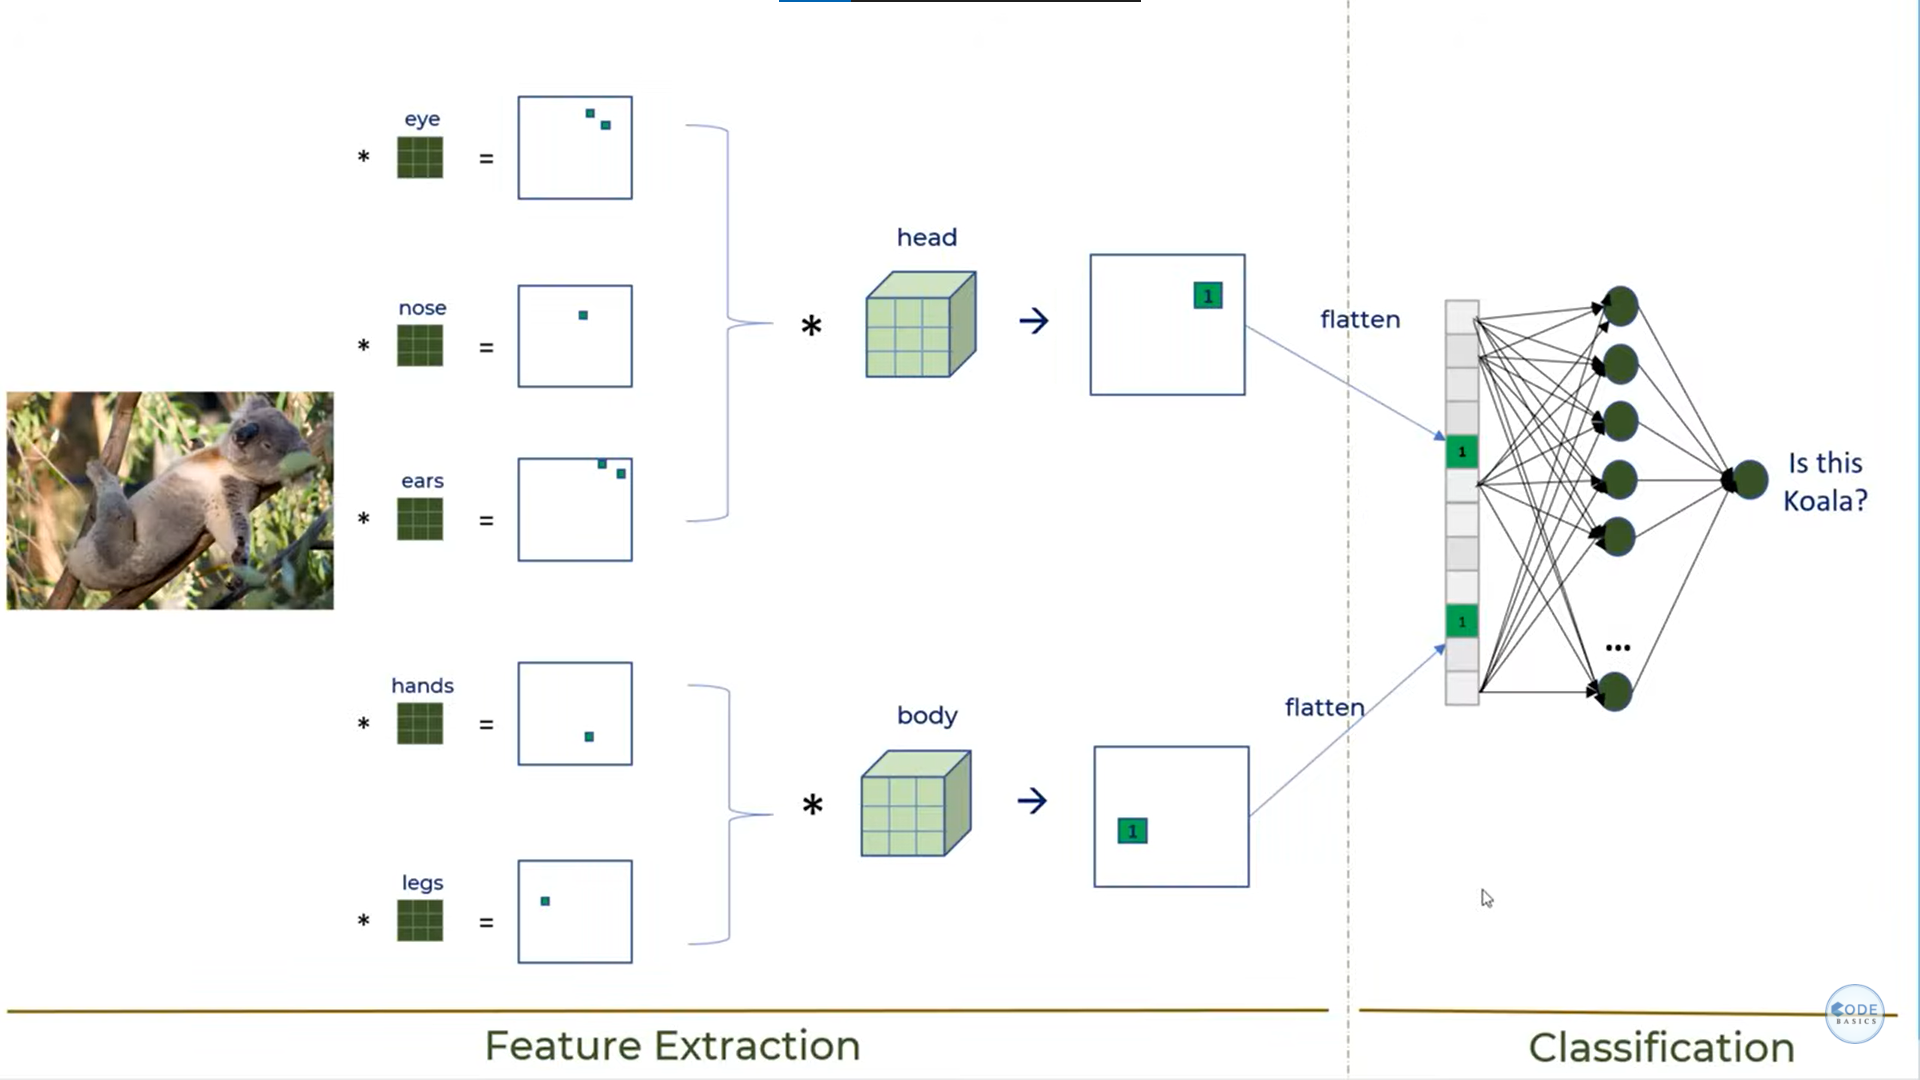
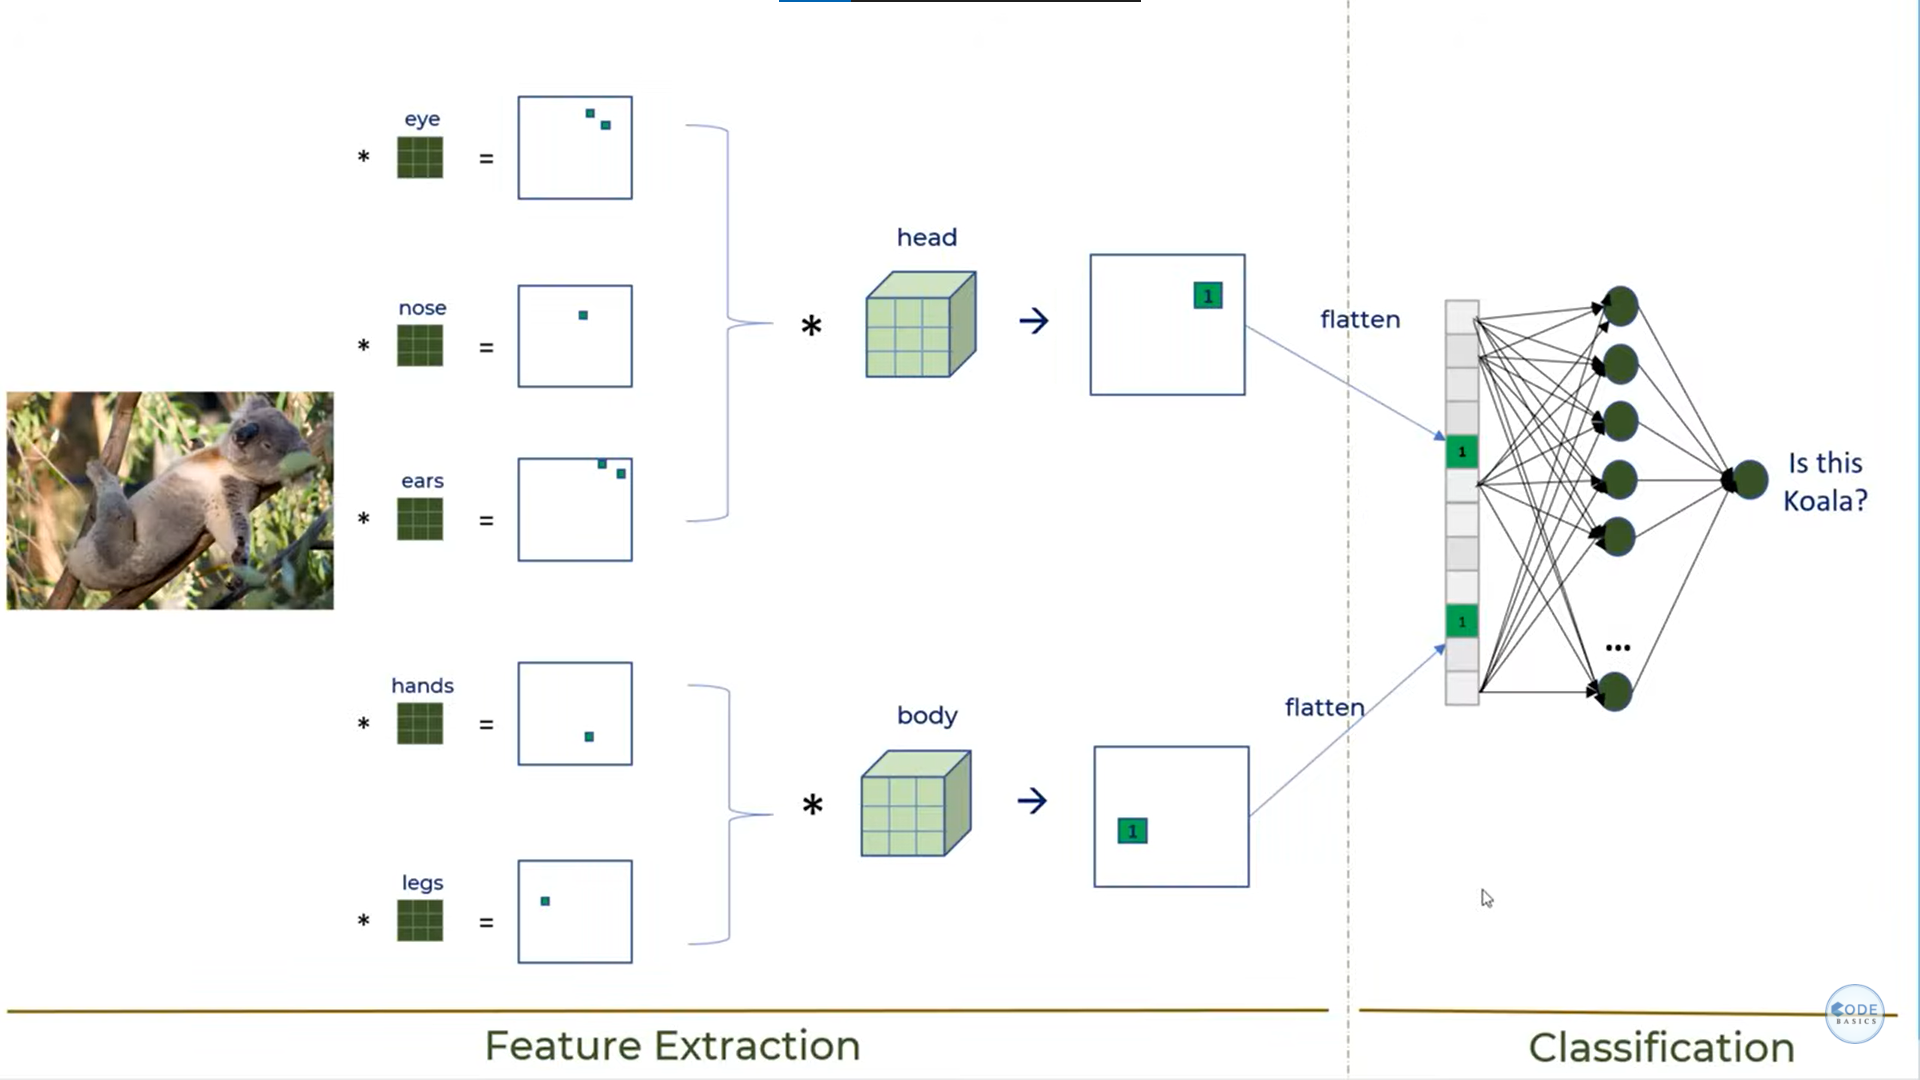
## Polling reduces the size of image
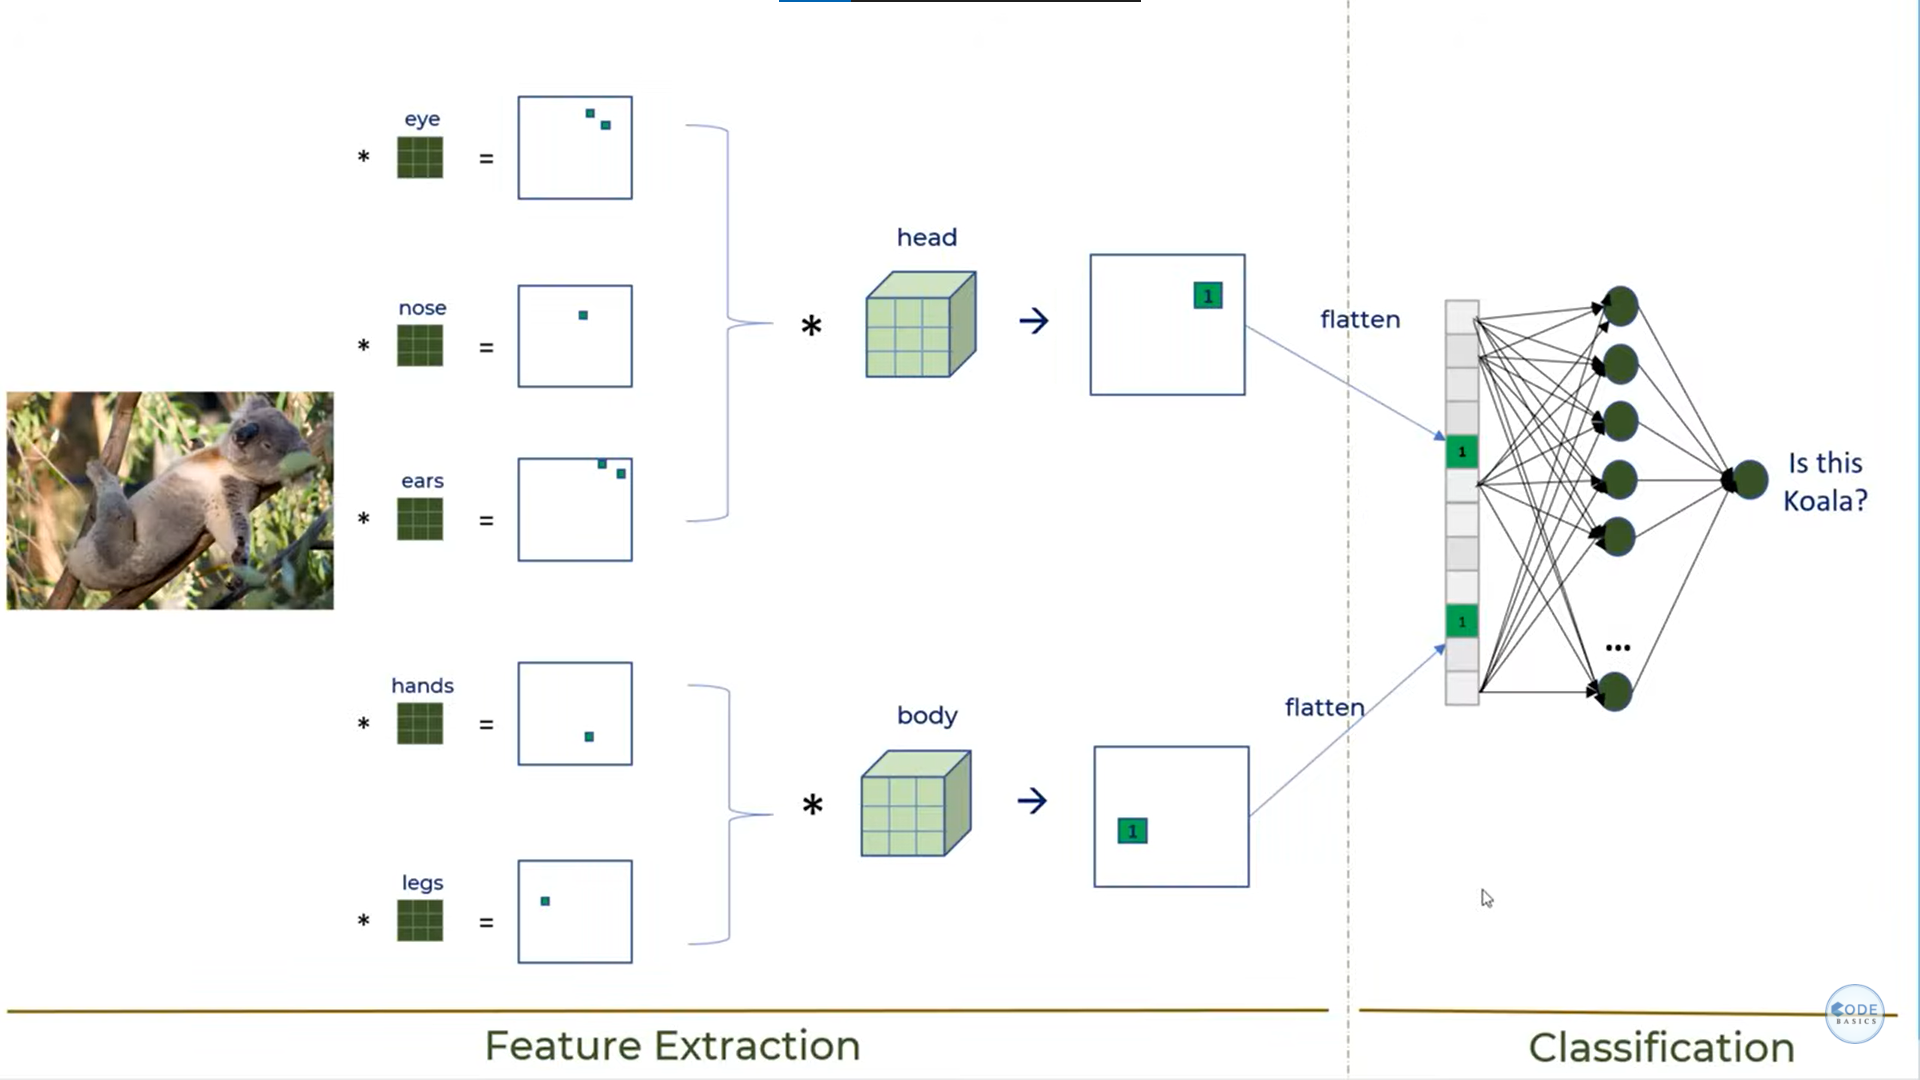
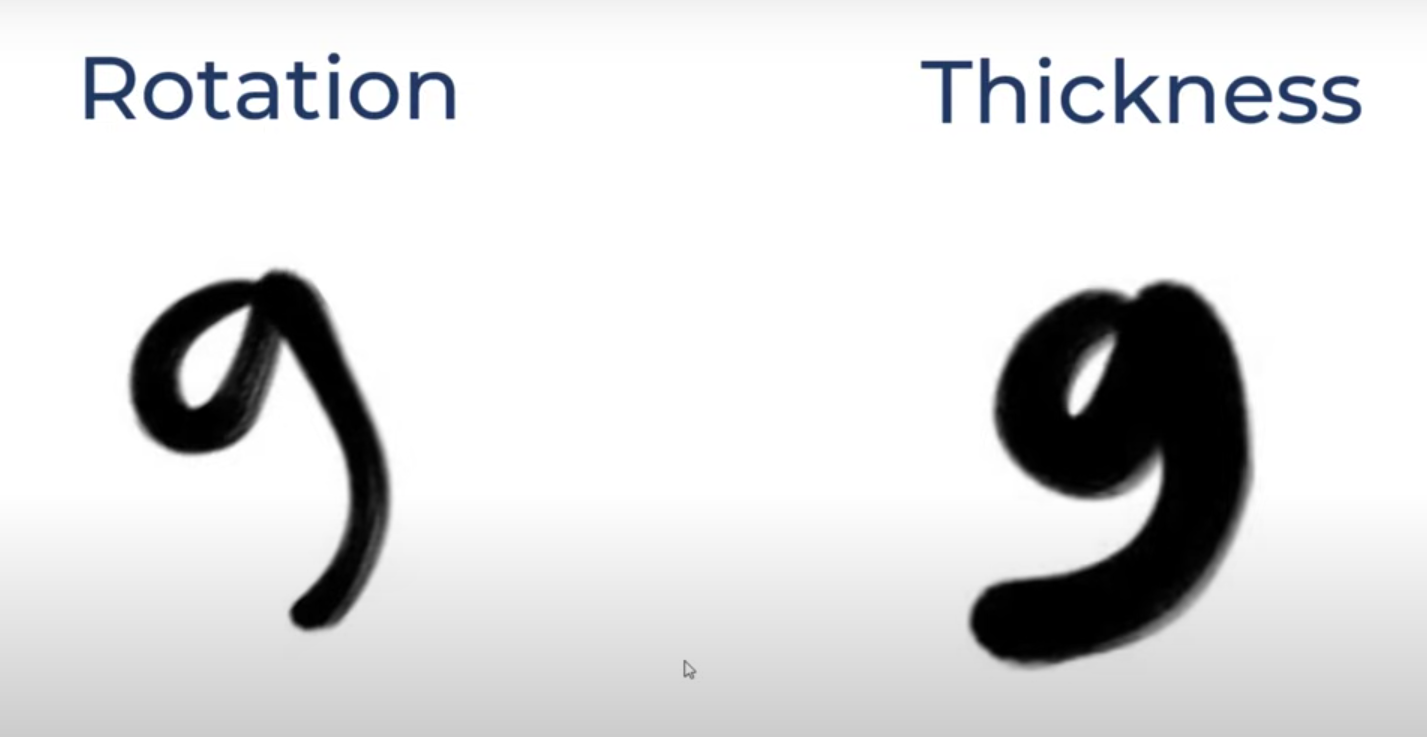
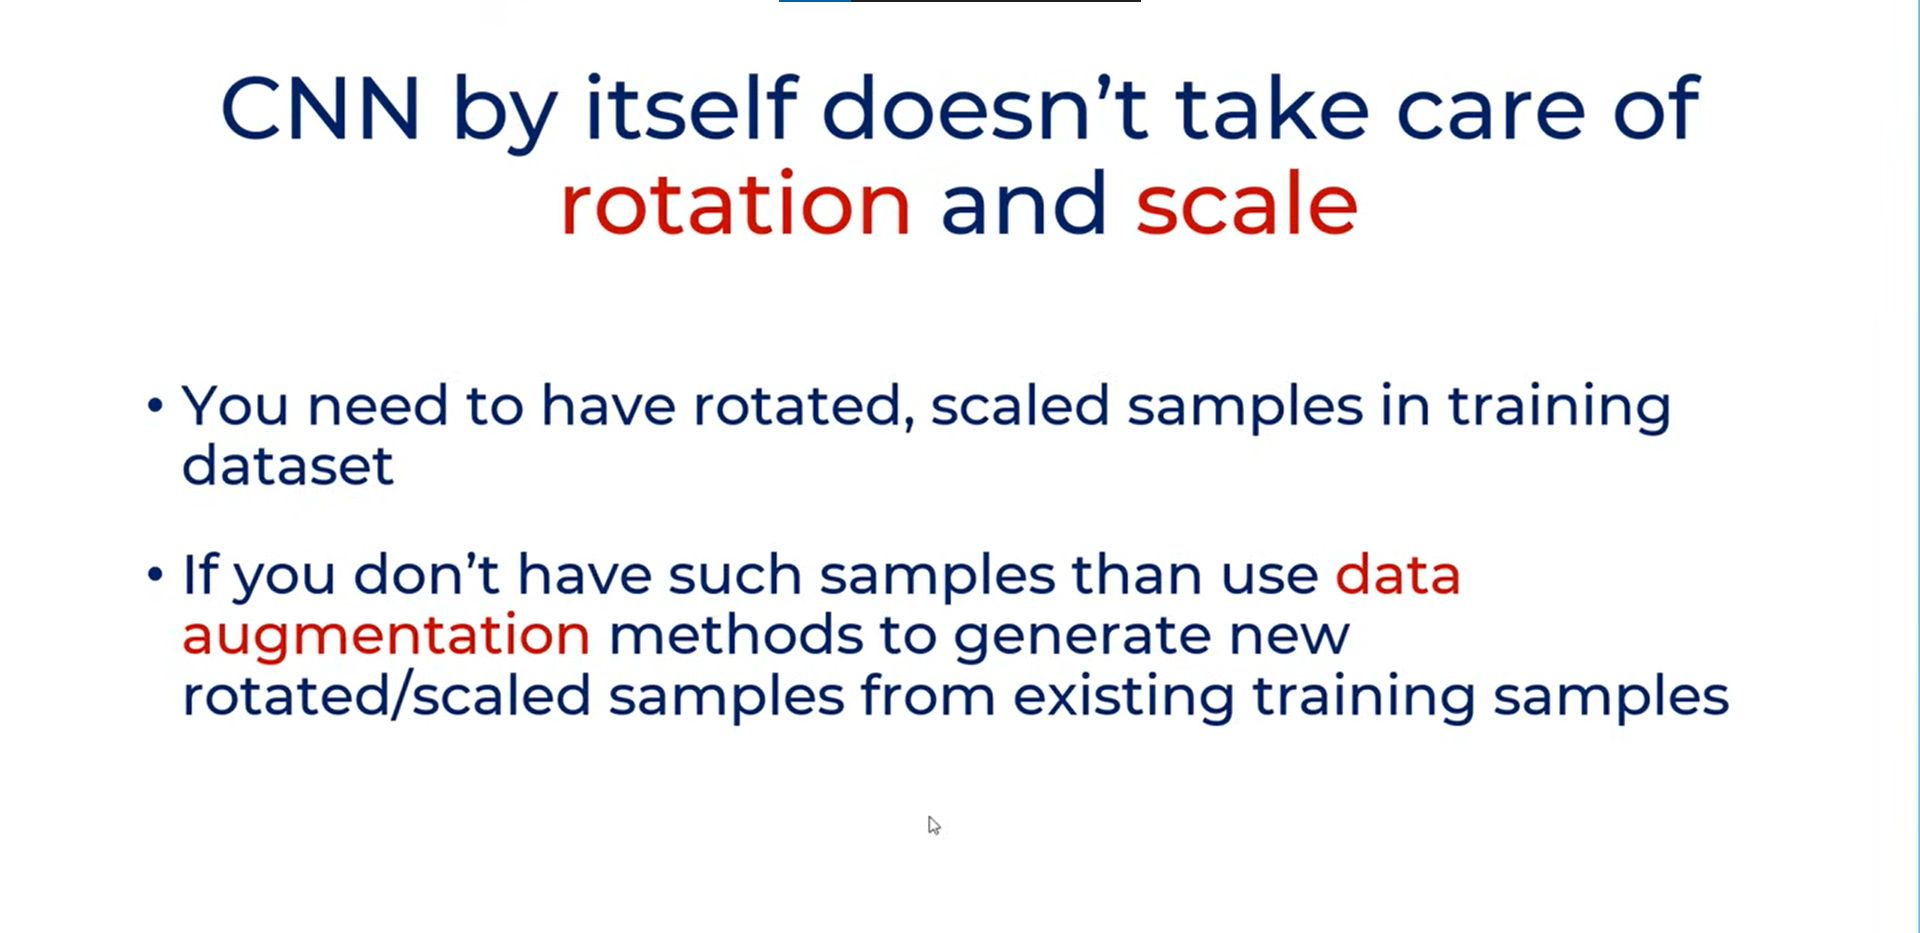

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [5]:
(X_train,y_train), (X_test,y_test)= keras.datasets.cifar10.load_data()
X_train.shape,X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [6]:
y_train.shape

(50000, 1)

In [7]:
# Lets convert y_train to one dim array
y_train = y_train.reshape(-1,) # Here when you dont want to change the first dim so you put -1 and blanck in the second to it will be flatten
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [8]:
from matplotlib import pyplot as plt
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]


def plot_sample(X,y,index):
    plt.figure(figsize=(3,2))
    plt.imshow(X[index])
    plt.xlabel(f"Index: {y[index]} {classes[y[index]]}")

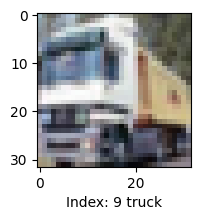

In [9]:
plot_sample(X_train,y_train,1)

In [10]:
X_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [11]:
# Lets scale the data
X_train = X_train / 255
X_test = X_test / 255

In [12]:
X_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [ ]:
ann = keras.Sequential([
    # Input Layer
    keras.layers.Flatten(input_shape=(32,32,3)),

    # Hidden Layers
    keras.layers.Dense(400,activation='relu'), # In hidden layers activation relu is preffered
    keras.layers.Dropout(0.5)
    keras.layers.Dense(200,activation='relu'), # In hidden layers activation relu is preffered
    keras.layers.Dropout(0.5)


    # Output layer
    keras.layers.Dense(10,activation='sigmoid'), # if you dont give any activation function its linear by default so it wont do any activation

])


ann.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy', # here we used categorical_crossentropy because when we use one hot encoding we use this but in out previous hand written digits classification we used sparse_categorical_crossentropy
    metrics=['accuracy']
)


ann.fit(X_train,y_train,epochs=50)


c:\Users\Nabeel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
 779/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.2657 - loss: 2.0260

KeyboardInterrupt: 

In [ ]:
ann.evaluate(X_test,y_test)

NameError: name 'ann' is not defined